# 2.0-feature-engineering

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import pairwise
from recruit_restaurant_visitor_forecasting.config.config import (
    AIR_AREA_COL,
    AIR_GENRE_COL,
    AIR_RESTAURANT_ID_COL,
    CALENDAR_DATE_COL,
    HPG_RESTAURANT_ID_COL,
    LATITUDE_COL,
    LONGITUDE_COL,
    VISIT_DATE_COL,
    VISITORS_COL,
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
    RAW_DATA_DIR,
    RANDOM_SEED,
    PROJ_ROOT,
    HOLIDAY_COL,
)
from recruit_restaurant_visitor_forecasting.config.features import (
    CITY_COL,
    DAY_OF_WEEK_COL,
    DAYS_OF_WEEK,
    OPEN_DATE_COL,
    RESERVE_AIR_COL,
    RESERVE_AIR_NBR_COL,
    RESERVE_HPG_COL,
    RESERVE_HPG_NBR_COL,
    TOTAL_RES_COL,
    TOTAL_RES_NBR_COL,
    VISITORS_NBR_COL,
    VISITORS_DOW_MEAN_COL,
    VISITORS_DOW_MEAN_NBR_COL,
    RES_VISITORS_DIFF_COL,
    RES_VISITORS_DIFF_NBR_COL,
    GENRE_TE,
    AREA_TE,
    MEAN_PREF,
    MAX_PREF,
    MEDIAN_PREF,
    OPEN_USUALLY_COL,
    MIN_PREF,
    STD_PREF,
    RES_IMPOSSIBILITY_COL,
    AGG_WINDOWS,
)
from recruit_restaurant_visitor_forecasting.dataset import (
    prepare_datetime_columns, standardize_date
)
from recruit_restaurant_visitor_forecasting.features import (
    add_basic_stats,
    add_golden_week_flg,
    add_historical_dow_mean,
    add_holiday_columns,
    add_lags,
    add_last_month_visitors,
    add_nbrs_reserves,
    add_neighbors_stats,
    add_opened_recently_flg,
    add_reserves_difference,
    add_sum_of_reserves,
    add_time_based_target_encoding,
    add_total_nbr_reservations,
    add_total_reservations,
    drop_first_month,
    add_open_usually_col,
    add_reservation_impossibility,
    select_by_vif
)
from recruit_restaurant_visitor_forecasting.config.feature_names import agg_window_col
from recruit_restaurant_visitor_forecasting.plots import plot_corr_matrix, plot_pairs_rel
from recruit_restaurant_visitor_forecasting.utils import get_pairs_by_corr

2026-04-08 19:11:41.970 | INFO     | recruit_restaurant_visitor_forecasting.config.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
air_visit_df = pd.read_csv(INTERIM_DATA_DIR / 'air_visit.csv')
air_reserve_df = pd.read_csv(INTERIM_DATA_DIR / 'air_reserve.csv')
hpg_reserve_df = pd.read_csv(INTERIM_DATA_DIR / 'hpg_reserve.csv', dtype={AIR_RESTAURANT_ID_COL: str})
future_df = pd.read_csv(INTERIM_DATA_DIR / 'sample_submission.csv')
air_store_df = pd.read_csv(INTERIM_DATA_DIR / 'air_store_info.csv')
hpg_store_df = pd.read_csv(INTERIM_DATA_DIR / 'hpg_store_info.csv')
date_info_df = pd.read_csv(RAW_DATA_DIR / 'date_info.csv')
store_rel_df = pd.read_csv(RAW_DATA_DIR / 'store_id_relation.csv')

In [3]:
prepare_datetime_columns(air_reserve_df)
prepare_datetime_columns(hpg_reserve_df)

standardize_date(date_info_df, CALENDAR_DATE_COL)
standardize_date(air_visit_df, VISIT_DATE_COL)
standardize_date(future_df, VISIT_DATE_COL)

## Features

### Air & hpg stores

In [4]:
air_store_df = air_store_df.drop([AIR_AREA_COL, LATITUDE_COL, LONGITUDE_COL], axis=1)

### Reserve dataframes

For further work, it is necessary to know the total number of reservations in the restaurant per day.

In [5]:
air_res_sum = add_sum_of_reserves(air_reserve_df, RESERVE_AIR_COL)
air_res_sum = air_res_sum.merge(
    air_store_df[[AIR_RESTAURANT_ID_COL, CITY_COL]],
    on=AIR_RESTAURANT_ID_COL
)
air_res_sum = add_nbrs_reserves(air_res_sum, RESERVE_AIR_COL, CITY_COL, RESERVE_AIR_NBR_COL)
air_res_sum.head()

,air_store_id,visit_date,air_reserves,city,air_reserves_nbrs
0,air_00a91d42b08b08d9,2016-10-31,2,Tōkyō-to,7.829268
1,air_00a91d42b08b08d9,2016-12-05,9,Tōkyō-to,9.754717
2,air_00a91d42b08b08d9,2016-12-14,18,Tōkyō-to,13.726027
3,air_00a91d42b08b08d9,2016-12-17,2,Tōkyō-to,20.884211
4,air_00a91d42b08b08d9,2016-12-20,4,Tōkyō-to,14.944444


In [6]:
air_res_sum[RESERVE_AIR_NBR_COL].isna().sum()

np.int64(0)

However, air_reserve dataframe still has a large number of gaps.

In [7]:
hpg_res_sum = add_sum_of_reserves(hpg_reserve_df, RESERVE_HPG_COL, HPG_RESTAURANT_ID_COL)
hpg_res_sum = hpg_res_sum.merge(
    hpg_store_df[[HPG_RESTAURANT_ID_COL, CITY_COL]],
    on=HPG_RESTAURANT_ID_COL
)
hpg_res_sum = add_nbrs_reserves(hpg_res_sum, RESERVE_HPG_COL, CITY_COL, RESERVE_HPG_NBR_COL)
hpg_res_sum.head()

,hpg_store_id,visit_date,hpg_reserves,city,hpg_reserves_nbrs
0,hpg_001ce40a1f873e4f,2016-01-13,4,Ōsaka-fu,5.573913
1,hpg_001ce40a1f873e4f,2016-01-27,7,Ōsaka-fu,6.202614
2,hpg_001ce40a1f873e4f,2016-02-13,2,Ōsaka-fu,6.532915
3,hpg_001ce40a1f873e4f,2016-02-27,8,Ōsaka-fu,7.452012
4,hpg_001ce40a1f873e4f,2016-03-16,2,Ōsaka-fu,7.291892


In [8]:
hpg_res_sum[RESERVE_HPG_NBR_COL].isna().sum()

np.int64(0)

In [9]:
hpg_res_sum_mapped = hpg_res_sum.merge(
    store_rel_df,
    on=HPG_RESTAURANT_ID_COL
)

### Date info

It is necessary to add a feature for the distance to the nearest holiday.

In [10]:
date_info_df = add_holiday_columns(date_info_df, CALENDAR_DATE_COL)

It is also necessary to designate Golden Week, since not all days of this week are holidays.

In [11]:
date_info_df = add_golden_week_flg(date_info_df, [2016, 2017], CALENDAR_DATE_COL)

Later we will need to match the weekday of a selected date with the restaurant’s open/closed flag for that weekday, so it makes sense to rename the days.

In [12]:
FULL_WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
mapping = dict(zip(FULL_WEEKDAYS, DAYS_OF_WEEK))
date_info_df[DAY_OF_WEEK_COL] = date_info_df[DAY_OF_WEEK_COL].replace(mapping)

### Air visit

#### Start dates

We can consider the restaurant's opening date. Since simply counting the number of days since opening may not be sufficient due to the increase in days over time, it's best to flag the restaurant's opening as occurring within the last six months. A **potential issue**: some restaurants either planned to open earlier than their minimum opening date but didn't, or didn't report visitors for earlier dates. This is indicated by the fact that air_reserve dataframe has reservations for earlier dates.

In [13]:
air_open_dates = (
    air_visit_df.groupby(AIR_RESTAURANT_ID_COL)[VISIT_DATE_COL]
    .min()
    .rename(OPEN_DATE_COL)
)

In [14]:
air_visit_df = add_opened_recently_flg(
    air_visit_df, air_open_dates, VISIT_DATE_COL, AIR_RESTAURANT_ID_COL
)
future_df = add_opened_recently_flg(
    future_df, air_open_dates, VISIT_DATE_COL, AIR_RESTAURANT_ID_COL
)

In [15]:
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1


In [16]:
future_df.head()

,id,visitors,air_store_id,visit_date,open_date,opened_recently
0,air_00a91d42b08b08d9_2017-04-23,0,air_00a91d42b08b08d9,2017-04-23,2016-07-01,0
1,air_00a91d42b08b08d9_2017-04-24,0,air_00a91d42b08b08d9,2017-04-24,2016-07-01,0
2,air_00a91d42b08b08d9_2017-04-25,0,air_00a91d42b08b08d9,2017-04-25,2016-07-01,0
3,air_00a91d42b08b08d9_2017-04-26,0,air_00a91d42b08b08d9,2017-04-26,2016-07-01,0
4,air_00a91d42b08b08d9_2017-04-27,0,air_00a91d42b08b08d9,2017-04-27,2016-07-01,0


#### Open dates

In [17]:
air_visit_df = air_visit_df.merge(
    date_info_df,
    left_on=VISIT_DATE_COL,
    right_on=CALENDAR_DATE_COL
).merge(
    air_store_df,
    on=AIR_RESTAURANT_ID_COL
).drop(CALENDAR_DATE_COL, axis=1)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,city
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,Tōkyō-to
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,Tōkyō-to
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,Tōkyō-to
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,Tōkyō-to
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,Tōkyō-to


In [18]:
air_visit_df = add_open_usually_col(air_visit_df)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,city,open_usually
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,Tōkyō-to,0.763690
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,Tōkyō-to,0.674355
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,Tōkyō-to,0.002113
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,Tōkyō-to,0.717011
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,Tōkyō-to,0.801409


Open_usually feature contains the probability that a restaurant will be open on a given day. It depends on the holiday feature, the percentage of non-zeros on holidays, and on individual days of the week.

In [19]:
# TODO: add open_usually feature to the future_df
future_df = future_df.merge(
    date_info_df,
    left_on=VISIT_DATE_COL,
    right_on=CALENDAR_DATE_COL
).merge(
    air_store_df,
    on=AIR_RESTAURANT_ID_COL
).drop(CALENDAR_DATE_COL, axis=1)
# future_df = add_open_usually(future_df)
# future_df.head()

#### Mean visitors by air city.

It is necessary to make smoothed target encoding, while the average value will be used for new areas. In this case, it is worth considering only days when the number of visitors is not zero, so that only open restaurants are taken into account.

In [22]:
air_visit_df, future_df = add_time_based_target_encoding(
    air_visit_df,
    future_df,
    CITY_COL,
    VISITORS_COL,
    AREA_TE
)

In [23]:
air_visit_df[
    [AIR_RESTAURANT_ID_COL, VISITORS_COL, AREA_TE, CITY_COL, VISIT_DATE_COL]
].head()

,air_store_id,visitors,air_city_te,city,visit_date
0,air_00a91d42b08b08d9,35,21.594815,Tōkyō-to,2016-07-01
1,air_00a91d42b08b08d9,9,21.655160,Tōkyō-to,2016-07-02
2,air_00a91d42b08b08d9,0,21.718513,Tōkyō-to,2016-07-03
3,air_00a91d42b08b08d9,20,21.722930,Tōkyō-to,2016-07-04
4,air_00a91d42b08b08d9,25,21.661642,Tōkyō-to,2016-07-05


In [24]:
future_df[[AIR_RESTAURANT_ID_COL, AREA_TE, CITY_COL, VISIT_DATE_COL]].head()

,air_store_id,air_city_te,city,visit_date
0,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-23
1,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-24
2,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-25
3,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-26
4,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-27


#### Mean visitors by air genre

It is necessary to make smoothed target encoding, while the average value will be used for new genres.

In [25]:
air_visit_df, future_df = add_time_based_target_encoding(
    air_visit_df,
    future_df,
    AIR_GENRE_COL,
    VISITORS_COL,
    GENRE_TE
)

In [26]:
air_visit_df[
    [AIR_RESTAURANT_ID_COL, VISITORS_COL, GENRE_TE, AIR_GENRE_COL, VISIT_DATE_COL]
].head()

,air_store_id,visitors,air_genre_te,air_genre_name,visit_date
0,air_00a91d42b08b08d9,35,22.490114,Italian/French,2016-07-01
1,air_00a91d42b08b08d9,9,22.540151,Italian/French,2016-07-02
2,air_00a91d42b08b08d9,0,22.600815,Italian/French,2016-07-03
3,air_00a91d42b08b08d9,20,22.619089,Italian/French,2016-07-04
4,air_00a91d42b08b08d9,25,22.563322,Italian/French,2016-07-05


In [27]:
future_df[[AIR_RESTAURANT_ID_COL, GENRE_TE, AIR_GENRE_COL, VISIT_DATE_COL]].head()

,air_store_id,air_genre_te,air_genre_name,visit_date
0,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-23
1,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-24
2,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-25
3,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-26
4,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-27


#### Total reserved visitors

Total reserved visitors (from air_reserve and hpg_reserve) on this day - for this restaurant/for neighbors.

By neighbors, we designate restaurants that are located in the same city.

In [28]:
air_visit_df = add_reservation_impossibility(air_visit_df, air_res_sum, hpg_res_sum_mapped)
air_visit_df = add_total_reservations(air_visit_df, air_res_sum, hpg_res_sum_mapped, CITY_COL)
air_visit_df = add_total_nbr_reservations(air_visit_df, hpg_res_sum, CITY_COL)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,city,open_usually,days_from_last_visit,air_city_te,air_genre_te,reservation_impossibility_flag,total_reservations,total_reservations_nbrs
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,Tōkyō-to,0.763690,0,21.594815,22.490114,0,0.0,8.308399
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,Tōkyō-to,0.674355,0,21.655160,22.540151,0,0.0,7.821683
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,Tōkyō-to,0.002113,0,21.718513,22.600815,0,0.0,6.256637
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,Tōkyō-to,0.717011,0,21.722930,22.619089,0,0.0,6.464730
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,Tōkyō-to,0.801409,0,21.661642,22.563322,0,0.0,6.811377


In [29]:
future_df = add_reservation_impossibility(future_df, air_res_sum, hpg_res_sum_mapped)
future_df = add_total_reservations(future_df, air_res_sum, hpg_res_sum_mapped, CITY_COL)
future_df = add_total_nbr_reservations(future_df, hpg_res_sum, CITY_COL)
future_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,city,open_usually,days_from_last_visit,id,air_city_te,air_genre_te,reservation_impossibility_flag,total_reservations,total_reservations_nbrs
0,air_00a91d42b08b08d9,2017-04-23,0,2016-07-01,0,Sun,0,-6,0,Italian/French,Tōkyō-to,20.953822,0,air_00a91d42b08b08d9_2017-04-23,20.700926,22.565297,0,0.0,7.325949
1,air_00a91d42b08b08d9,2017-04-24,0,2016-07-01,0,Mon,0,-5,0,Italian/French,Tōkyō-to,20.953822,1,air_00a91d42b08b08d9_2017-04-24,20.700926,22.565297,0,0.0,9.696673
2,air_00a91d42b08b08d9,2017-04-25,0,2016-07-01,0,Tue,0,-4,0,Italian/French,Tōkyō-to,20.953822,2,air_00a91d42b08b08d9_2017-04-25,20.700926,22.565297,0,0.0,8.652330
3,air_00a91d42b08b08d9,2017-04-26,0,2016-07-01,0,Wed,0,-3,0,Italian/French,Tōkyō-to,20.953822,3,air_00a91d42b08b08d9_2017-04-26,20.700926,22.565297,0,0.0,11.196581
4,air_00a91d42b08b08d9,2017-04-27,0,2016-07-01,0,Th,0,-2,0,Italian/French,Tōkyō-to,20.953822,4,air_00a91d42b08b08d9_2017-04-27,20.700926,22.565297,0,0.0,9.380583


#### Rolling mean/median/std of visitors

If open_usually == 0 and visitors == 0, the value is replaced with NaN. Otherwise, zero is included in the aggregation. Later, we need to take care of the initial rows of the window, because right now they contain non-NaN values, even though conceptually they should be NaN.

In [30]:
aggs = [
    ("mean", {}),
    ("median", {}),
    ("std", {"ddof": 0}),
    ("max", {}),
    ("min", {}),
]
air_visit_df = add_basic_stats(air_visit_df, VISITORS_COL, AIR_RESTAURANT_ID_COL, aggs=aggs)
air_visit_df = add_neighbors_stats(air_visit_df, VISITORS_COL, CITY_COL)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_nbrs,visitors_nbrs_mean_7,visitors_nbrs_median_7,visitors_nbrs_std_7,visitors_nbrs_mean_14,visitors_nbrs_median_14,visitors_nbrs_std_14,visitors_nbrs_mean_28,visitors_nbrs_median_28,visitors_nbrs_std_28
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,...,25.002169,19.336626,19.526596,3.677489,18.877660,17.396277,3.977306,18.386208,17.204787,4.030923
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,...,23.873391,19.491191,19.526596,3.883838,18.889973,17.396277,3.995937,18.480891,17.204787,4.152251
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,...,15.205567,19.384958,19.526596,3.750046,18.836856,17.396277,3.923747,18.502395,17.204787,4.178481
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,...,13.262260,19.040465,19.526596,3.999123,18.785430,17.396277,3.966056,18.494729,17.204787,4.184321
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,...,16.851064,19.027019,19.526596,4.018324,18.814801,17.396277,3.923292,18.544179,17.204787,4.113409


#### Visitors on the same day last month


The feature has a drawback: if the previous month had 30 days and the current month has 31, then the feature for the 31st day will correspond to the 30th day. If there were 0 visitors, and the open_usually flag is 0, then 0 visitors are indicated.

In [31]:
air_visit_df = add_last_month_visitors(air_visit_df, VISITORS_COL)
air_visit_df.tail()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_nbrs_mean_7,visitors_nbrs_median_7,visitors_nbrs_std_7,visitors_nbrs_mean_14,visitors_nbrs_median_14,visitors_nbrs_std_14,visitors_nbrs_mean_28,visitors_nbrs_median_28,visitors_nbrs_std_28,visitors_last_month
296883,air_fff68b929994bfbd,2017-04-18,6,2016-07-01,0,Tue,0,-11,0,Bar/Cocktail,...,18.482179,17.764706,4.413689,18.288757,17.565923,3.975072,18.740510,18.389452,3.903701,8.0
296884,air_fff68b929994bfbd,2017-04-19,2,2016-07-01,0,Wed,0,-10,0,Bar/Cocktail,...,19.063460,18.125761,4.045145,18.386120,17.945233,3.953133,18.882280,18.389452,3.805484,2.0
296885,air_fff68b929994bfbd,2017-04-20,2,2016-07-01,0,Th,0,-9,0,Bar/Cocktail,...,19.271226,18.490872,3.989652,18.412199,17.945233,3.954715,18.900101,18.473631,3.803989,2.0
296886,air_fff68b929994bfbd,2017-04-21,4,2016-07-01,0,Fri,0,-8,0,Bar/Cocktail,...,19.199073,18.125761,4.007639,18.458563,18.055781,3.945629,18.846711,18.291075,3.805955,2.0
296887,air_fff68b929994bfbd,2017-04-22,5,2016-07-01,0,Sat,0,-7,0,Bar/Cocktail,...,19.223703,18.125761,4.035037,18.566068,18.055781,4.066548,18.820414,18.291075,3.769120,1.0


#### Visitors lag features

In [32]:
air_visit_df = add_lags(air_visit_df, AIR_RESTAURANT_ID_COL, VISITORS_COL)
air_visit_df = add_lags(air_visit_df, CITY_COL, VISITORS_NBR_COL, True)
air_visit_df.tail()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_nbrs_mean_28,visitors_nbrs_median_28,visitors_nbrs_std_28,visitors_last_month,visitors_lag_1,visitors_lag_7,visitors_lag_28,visitors_nbrs_lag_1,visitors_nbrs_lag_7,visitors_nbrs_lag_28
283173,air_f267dd70a6a6b5d3,2017-04-22,44,2016-07-01,0,Sat,0,-7,0,Creative cuisine,...,20.162759,20.038168,5.33417,5.0,9.0,59.0,60.0,24.641221,28.633588,31.89313
289253,air_f927b2da69a82341,2017-04-22,7,2016-01-04,0,Sat,0,-7,0,Japanese food,...,20.162759,20.038168,5.33417,0.0,13.0,9.0,14.0,24.641221,28.633588,31.89313
294159,air_fdc02ec4a3d21ea4,2017-04-22,9,2016-07-01,0,Sat,0,-7,0,Dining bar,...,20.162759,20.038168,5.33417,1.0,4.0,26.0,32.0,24.641221,28.633588,31.89313
295999,air_fee8dcf4d619598e,2017-04-22,53,2016-07-01,0,Sat,0,-7,0,Italian/French,...,20.162759,20.038168,5.33417,27.0,27.0,47.0,45.0,24.641221,28.633588,31.89313
296295,air_fef9ccb3ba0da2f7,2017-04-22,5,2016-07-01,0,Sat,0,-7,0,Japanese food,...,20.162759,20.038168,5.33417,3.0,3.0,23.0,12.0,24.641221,28.633588,31.89313


#### Historical day-of-week mean of visitors


In [33]:
air_visit_df, future_df = add_historical_dow_mean(
    air_visit_df,
    VISITORS_COL,
    VISITORS_DOW_MEAN_COL,
    future_df
)
air_visit_df, future_df = add_historical_dow_mean(
    air_visit_df,
    VISITORS_NBR_COL,
    VISITORS_DOW_MEAN_NBR_COL,
    future_df
)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_nbrs_std_28,visitors_last_month,visitors_lag_1,visitors_lag_7,visitors_lag_28,visitors_nbrs_lag_1,visitors_nbrs_lag_7,visitors_nbrs_lag_28,visitors_dow_mean,visitors_dow_mean_nbrs
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,...,4.030923,NaN,NaN,NaN,NaN,19.526596,23.920213,22.351064,NaN,NaN
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,...,4.152251,NaN,35.0,NaN,NaN,25.002169,24.617021,23.271277,NaN,NaN
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,...,4.178481,NaN,9.0,NaN,NaN,23.873391,17.617021,15.420213,NaN,NaN
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,...,4.184321,NaN,0.0,NaN,NaN,15.205567,13.356383,11.877660,NaN,NaN
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,...,4.113409,NaN,20.0,NaN,NaN,13.262260,16.702128,15.936170,NaN,NaN


In [34]:
future_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,open_usually,days_from_last_visit,id,air_city_te,air_genre_te,reservation_impossibility_flag,total_reservations,total_reservations_nbrs,visitors_dow_mean,visitors_dow_mean_nbrs
0,air_00a91d42b08b08d9,2017-04-23,0,2016-07-01,0,Sun,0,-6,0,Italian/French,...,20.953822,0,air_00a91d42b08b08d9_2017-04-23,20.700926,22.565297,0,0.0,7.325949,0.048780,15.271142
1,air_00a91d42b08b08d9,2017-04-24,0,2016-07-01,0,Mon,0,-5,0,Italian/French,...,20.953822,1,air_00a91d42b08b08d9_2017-04-24,20.700926,22.565297,0,0.0,9.696673,18.707317,12.393976
2,air_00a91d42b08b08d9,2017-04-25,0,2016-07-01,0,Tue,0,-4,0,Italian/French,...,20.953822,2,air_00a91d42b08b08d9_2017-04-25,20.700926,22.565297,0,0.0,8.652330,22.902439,15.261884
3,air_00a91d42b08b08d9,2017-04-26,0,2016-07-01,0,Wed,0,-3,0,Italian/French,...,20.953822,3,air_00a91d42b08b08d9_2017-04-26,20.700926,22.565297,0,0.0,11.196581,27.024390,17.128945
4,air_00a91d42b08b08d9,2017-04-27,0,2016-07-01,0,Th,0,-2,0,Italian/French,...,20.953822,4,air_00a91d42b08b08d9_2017-04-27,20.700926,22.565297,0,0.0,9.380583,26.756098,16.976360


#### Rolling reserve/visitors difference


In [35]:
air_visit_df = add_reserves_difference(
    air_visit_df,
    VISITORS_COL,
    TOTAL_RES_COL,
    RES_VISITORS_DIFF_COL,
)
air_visit_df = add_reserves_difference(
    air_visit_df,
    VISITORS_NBR_COL,
    TOTAL_RES_NBR_COL,
    RES_VISITORS_DIFF_NBR_COL,
)

In [37]:
aggs = [("mean", {})]
air_visit_df = add_basic_stats(
    air_visit_df, RES_VISITORS_DIFF_COL, AIR_RESTAURANT_ID_COL, aggs
)
air_visit_df = add_neighbors_stats(
    air_visit_df, RES_VISITORS_DIFF_NBR_COL, CITY_COL, aggs, False
)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_dow_mean,visitors_dow_mean_nbrs,res_visitors_diff,res_visitors_diff_mean_7,res_visitors_diff_mean_14,res_visitors_diff_mean_28,nbr_res_visitors_diff,nbr_res_visitors_diff_mean_7,nbr_res_visitors_diff_mean_14,nbr_res_visitors_diff_mean_28
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,...,NaN,NaN,NaN,NaN,NaN,NaN,-11.317182,-10.590216,-10.775863,-10.846981
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,...,NaN,NaN,-35.0,NaN,NaN,NaN,-16.405267,-10.997068,-10.857126,-10.847153
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,...,NaN,NaN,-9.0,-35.000000,-35.000000,-35.000000,-15.759862,-11.460121,-10.908120,-10.940529
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,...,NaN,NaN,0.0,-22.000000,-22.000000,-22.000000,-8.794755,-11.440223,-10.863249,-10.938618
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,...,NaN,NaN,-20.0,-14.666667,-14.666667,-14.666667,-6.778340,-11.193490,-10.830944,-10.953180


#### NaN dropping

In [38]:
air_visit_df = drop_first_month(air_visit_df)
air_visit_df = air_visit_df.dropna()
air_visit_df = air_visit_df.sort_values(VISIT_DATE_COL)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_dow_mean,visitors_dow_mean_nbrs,res_visitors_diff,res_visitors_diff_mean_7,res_visitors_diff_mean_14,res_visitors_diff_mean_28,nbr_res_visitors_diff,nbr_res_visitors_diff_mean_7,nbr_res_visitors_diff_mean_14,nbr_res_visitors_diff_mean_28
244410,air_d0e8a085d8dc83aa,2016-02-01,10,2016-01-01,1,Mon,0,-10,0,Cafe/Sweets,...,15.75,16.126276,-18.0,-13.857143,-12.428571,-11.857143,-15.816327,-11.452008,-11.328331,-12.117069
253575,air_db4b38ebe7a7ceff,2016-02-01,14,2016-01-01,1,Mon,0,-10,0,Dining bar,...,12.00,16.126276,-10.0,-6.142857,-5.928571,-6.964286,-15.816327,-11.452008,-11.328331,-12.117069
241908,air_cfdeb326418194ff,2016-02-01,3,2016-01-01,1,Mon,0,-10,0,Bar/Cocktail,...,5.25,13.531875,0.0,-11.857143,-10.500000,-9.571429,-7.960708,-9.767062,-9.584126,-10.784374
61980,air_39dccf7df20b1c6a,2016-02-01,26,2016-01-01,1,Mon,0,-10,0,Izakaya,...,24.75,16.126276,-38.0,-18.714286,-21.928571,-23.571429,-15.816327,-11.452008,-11.328331,-12.117069
237464,air_cb7467aed805e7fe,2016-02-01,16,2016-01-01,1,Mon,0,-10,0,Izakaya,...,16.75,15.011974,-21.0,-30.142857,-27.428571,-25.821429,-9.822421,-7.854981,-8.580150,-10.476121


#### Saving

In [39]:
air_visit_df = air_visit_df.drop(columns=[OPEN_DATE_COL])
labels = air_visit_df[VISITORS_COL].copy()
features = air_visit_df.drop(columns=[VISITORS_COL])
future_df = future_df.drop(columns=[OPEN_DATE_COL, "id", VISITORS_COL])
future_df[TOTAL_RES_NBR_COL] = future_df[TOTAL_RES_NBR_COL].fillna(0)
features.to_csv(PROCESSED_DATA_DIR / "features.csv", index=False)
labels.to_csv(PROCESSED_DATA_DIR / "labels.csv", index=False)
future_df.to_csv(PROCESSED_DATA_DIR / "test_features.csv", index=False)

## Feature correlation

In [40]:
corr = air_visit_df.corr(numeric_only=True)
corr.to_csv(PROJ_ROOT / "reports/tables/correlation_after_clustering.csv")
plot_corr_matrix(corr)

In [41]:
CORRELATION_THRESHOLD = 0.8
get_pairs_by_corr(corr, CORRELATION_THRESHOLD).index.tolist()

[('visitors_mean_7', 'visitors_median_7'),
 ('visitors_mean_7', 'visitors_max_7'),
 ('visitors_mean_7', 'visitors_mean_14'),
 ('visitors_mean_7', 'visitors_median_14'),
 ('visitors_mean_7', 'visitors_mean_28'),
 ('visitors_mean_7', 'visitors_median_28'),
 ('visitors_mean_7', 'res_visitors_diff_mean_7'),
 ('visitors_mean_7', 'res_visitors_diff_mean_14'),
 ('visitors_mean_7', 'res_visitors_diff_mean_28'),
 ('visitors_median_7', 'visitors_mean_14'),
 ('visitors_median_7', 'visitors_median_14'),
 ('visitors_median_7', 'visitors_mean_28'),
 ('visitors_median_7', 'visitors_median_28'),
 ('visitors_median_7', 'res_visitors_diff_mean_7'),
 ('visitors_median_7', 'res_visitors_diff_mean_14'),
 ('visitors_std_7', 'visitors_max_7'),
 ('visitors_std_7', 'visitors_std_14'),
 ('visitors_std_7', 'visitors_max_14'),
 ('visitors_std_7', 'visitors_std_28'),
 ('visitors_max_7', 'visitors_mean_14'),
 ('visitors_max_7', 'visitors_std_14'),
 ('visitors_max_7', 'visitors_max_14'),
 ('visitors_min_7', 'visitor

In [42]:
sample = air_visit_df.sample(10000, random_state=RANDOM_SEED)

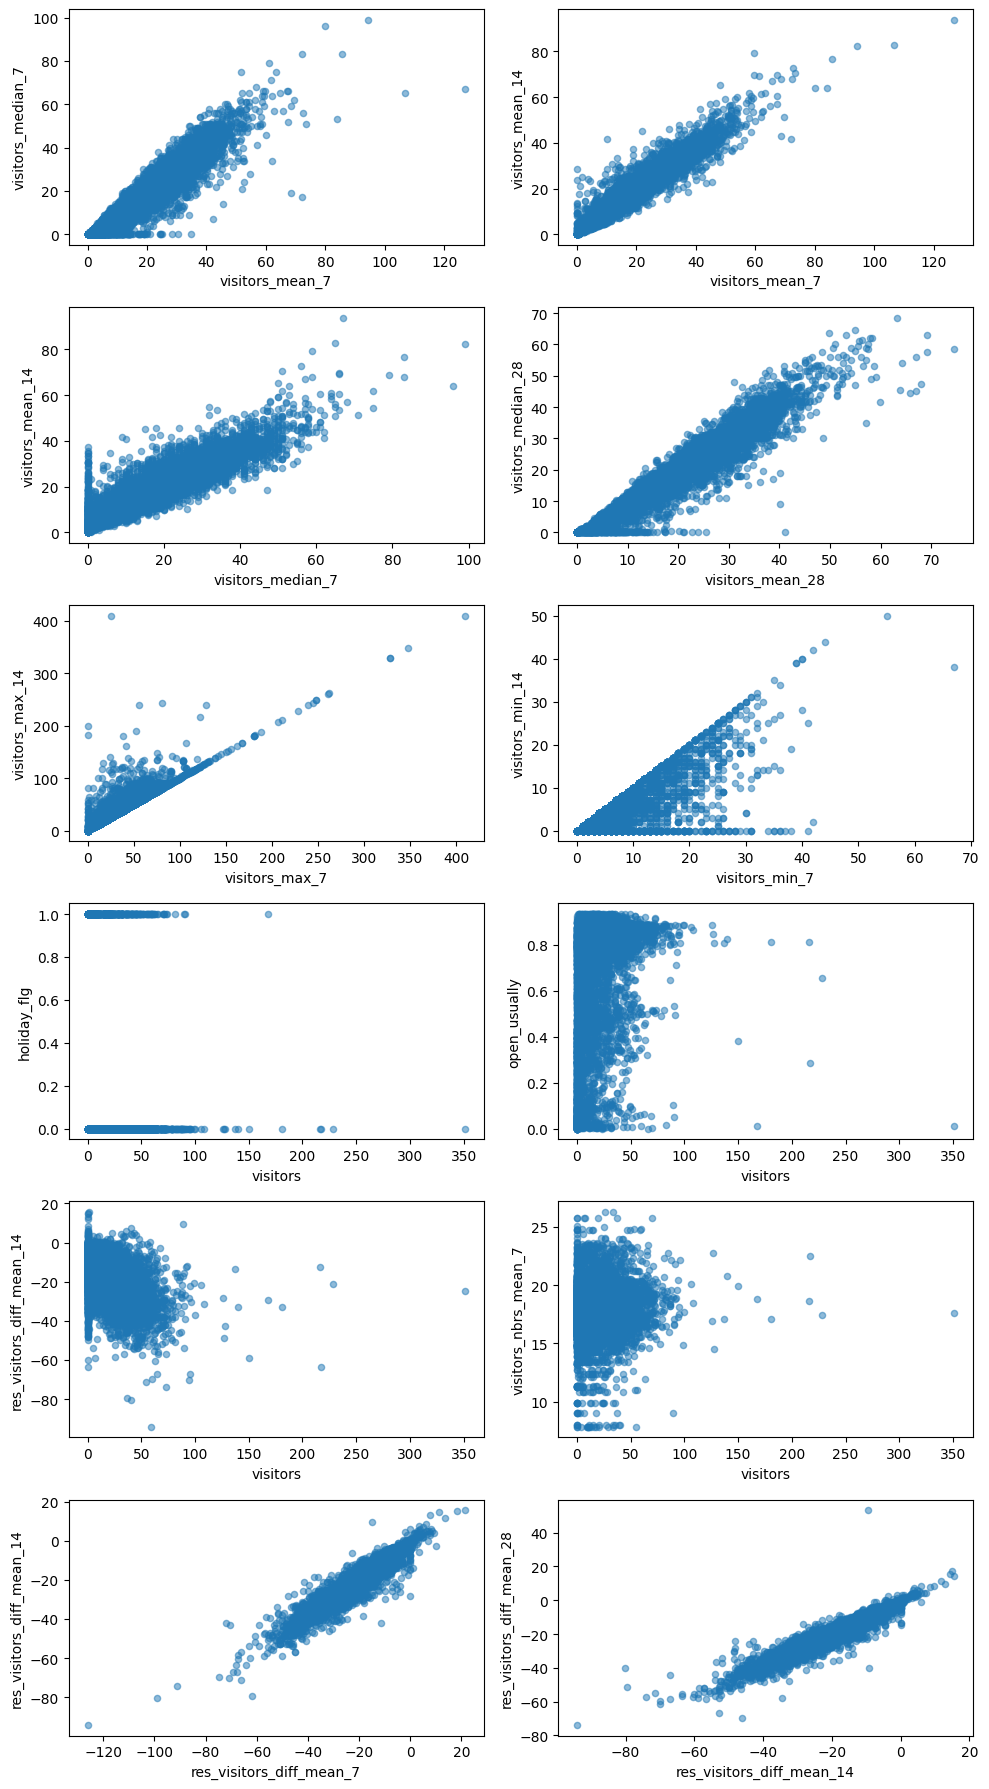

In [43]:
pairs = [
    ((MEAN_PREF, 7), (MEDIAN_PREF, 7)),
    ((MEAN_PREF, 7), (MEAN_PREF, 14)),
    ((MEDIAN_PREF, 7), (MEAN_PREF, 14)),
    ((MEAN_PREF, 28), (MEDIAN_PREF, 28)),
    ((MAX_PREF, 7), (MAX_PREF, 14)),
    ((MIN_PREF, 7), (MIN_PREF, 14))
]
pairs = [
    tuple(agg_window_col(VISITORS_COL, *item) for item in pair) for pair in pairs
]
res_means = [agg_window_col(RES_VISITORS_DIFF_COL, MEAN_PREF, w) for w in AGG_WINDOWS]
pairs += [
    (VISITORS_COL, HOLIDAY_COL),
    (VISITORS_COL, OPEN_USUALLY_COL),
    (VISITORS_COL, res_means[1]),
    (VISITORS_COL, agg_window_col(VISITORS_NBR_COL, MEAN_PREF, 7)),
    *pairwise(res_means)
]
plot_pairs_rel(pairs, sample)

Holiday flag feature has approximately the same number of visitors at both 1 and 0, so the feature is uncorrelated and likely unnecessary for the model. Open usually has fewer visitors at 0, and more at 1, but both also contain zeros.
Reserve visitors difference mean 14 and visitors have a slightly elongated ellipsoid shape, indicating a relationship between the features.

Among the highly correlated features, the following can be retained: visitors_min_7 as more informative relative to visitors_min_14 (too many zeros can only interfere); max_7 as less noisy relative to max_14 and at the same time equally correlated with the target; mean_14 similarly relative to mean_7, median_7; median_28 similarly relative to mean_28; res_visitors_diff_mean_14 similarly relative to res_visitors_diff_mean_7, res_visitors_diff_mean_28; std_28 as the most correlated with the target and the least correlated with the selected max_14.

In [44]:
cols = []
for window in AGG_WINDOWS:
    for agg in [MIN_PREF, MEDIAN_PREF, MAX_PREF, MEAN_PREF, STD_PREF]:
        cols.append(agg_window_col(VISITORS_COL, agg, window))
    cols.append(agg_window_col(RES_VISITORS_DIFF_COL, MEAN_PREF, window))

select_by_vif(sample, cols)

['visitors_min_7',
 'visitors_std_7',
 'visitors_min_14',
 'visitors_min_28',
 'visitors_median_28',
 'visitors_max_28']

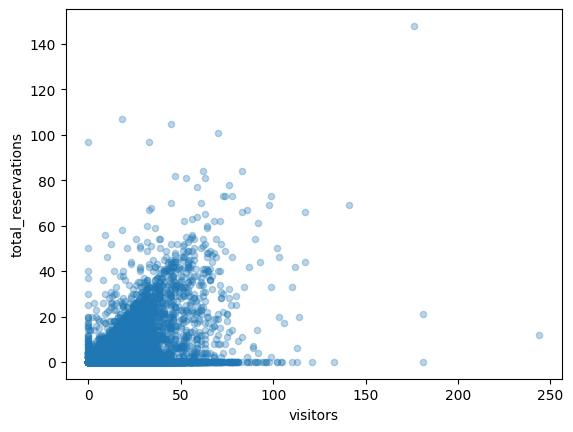

In [45]:
mask = air_visit_df[RES_IMPOSSIBILITY_COL] == 0
sample = air_visit_df[mask].sample(10000, random_state=RANDOM_SEED)
sample.plot.scatter(x=VISITORS_COL, y=TOTAL_RES_COL, alpha=0.3)
plt.show()

In [46]:
air_visit_df[mask][[VISITORS_COL, TOTAL_RES_COL]].corr()

,visitors,total_reservations
visitors,1.000000,0.316773
total_reservations,0.316773,1.000000


Even excluding restaurants for which reservations are impossible, the linear relationship between visitors and reservations is still weak (but the correlation is 0.13 higher than before the exclusion). However, we can see that there is a "boundary" above which the density of values is significantly lower. Situations where there are more reservations than visitors are less common, but not vice versa. There are also quite a few observations where the number of reservations is zero, but there are still many visitors. This isn't related to gaps in air_reserve, as we filled them previously.

### Correlation difference after clustering

In [47]:
corr_before = pd.read_csv(
    PROJ_ROOT / "reports/tables/correlation_before_clustering.csv",
    index_col=0
)

In [48]:
corr_diff = (corr.abs() - corr_before.abs()).reindex(index=corr.index, columns=corr.columns).round(2)
plot_corr_matrix(corr_diff, 0.5)

City clustering had virtually no effect on the correlation of visitors with the other features. However, initially, the correlation with "neighboring" features was weak (shown previously in the graph). While previously restaurants with a small number of neighbors might have had clear differences in visitor numbers and "neighboring" features, now the effect may be similar but different: large cities outshine small ones. Because of this, "neighboring" features will always be disadvantaged for representatives of small cities, regardless of whether clustering was used. Later we could compare models with clustered and non-clustered cities.

It is also clear that the correlation of various features with std has decreased, which is expected, since after clustering we obtain n cities with a large number of restaurants, and the strong dispersion of small cities is simply leveled out.

## Conclusion

### Added features.

- Operating schedule - regular working days, extracted from the regular gaps in the data frame.
- Days to/from the nearest holiday (negative is days until, positive is days after).
- Holiday indicator (currently included in date_info).
- Separate indicators for Golden Week dates.

- Number of visitors on this day last month for this restaurant.

- Indicator of whether the restaurant has been open within the last 6 months.
- Days since last recorded visit for air_visit dataframe.

- Rolling mean/median/std of visitors over the past week, month - for this restaurant/for neighbors.
- Historical day-of-week mean up to (but not including) the current day - for this restaurant/for neighbors.
- Rolling reserve/visitors difference over the past 7 / 28 days - for this restaurant/for neighbors.
- Lag 1, 7, 28 of the number of visitors - for this restaurant/for neighbors.

- Smoothed target encoding of visitors by air_area_name.
- Smoothed target encoding of visitors by air_genre_name.

- Total reserved visitors (from air_reserve and hpg_reserve) on this day - for this restaurant/for neighbors.

### Features planned for addition.

- Days since last recorded visit for sample_submission.

### Possible features.

- Daily temperature - try to get the weather forecast.
- Precipitation probability.
- Hpg genre.

Decomposition features:
- Trend.
- Trend difference for last month.
- Seasonal.
- Residual mean for last month.